### Imports

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb
import optuna

pio.templates.default = "plotly_white"
# pio.renderers.default='notebook'

### Load file

In [2]:
df = pd.read_csv("data/housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


### Inspect target

In [6]:
target = "median_house_value"

fig = px.histogram(df, x="median_house_value", nbins=50, marginal="box")
fig.update_layout(height=400, width=700, title_text="Median House Value (target feature)")
fig.show()

In [7]:
# The maximum value of the target feature is truncated to 500_001.

max_value_target = df["median_house_value"].max().item()
print(f"Maximum value of target feature: {max_value_target:.2f}")

df["median_house_value"].sort_values(ascending=False).head(10)

Maximum value of target feature: 500001.00


5253    500001.0
5254    500001.0
5255    500001.0
5256    500001.0
5257    500001.0
5258    500001.0
5259    500001.0
5260    500001.0
5261    500001.0
5262    500001.0
Name: median_house_value, dtype: float64

### Numerical features

In [8]:
plot_cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]

fig = make_subplots(rows=3, cols=2)
for i, col in enumerate(plot_cols):
    fig.add_trace(go.Histogram(x=df[col], name=col), row=i // 2 + 1, col=i % 2 + 1)
    fig.update_xaxes(title_text=col, row=i // 2 + 1, col=i % 2 + 1)
    fig.update_yaxes(title_text="Count", row=i // 2 + 1, col=i % 2 + 1)
fig.update_layout(height=600, width=1200, title_text="Distribution of numerical features")
fig.show()

In [9]:
fig = make_subplots(rows=3, cols=2)
for i, col in enumerate(plot_cols):
    fig.add_trace(go.Box(x=df[col], name=col), row=i // 2 + 1, col=i % 2 + 1)
fig.update_layout(height=600, width=1200, title_text="Box plot of numerical features")
fig.show()

In [10]:
# Numerical feature housing_median_age is also truncated, this time to 52.

max_value_feat = df["housing_median_age"].max().item()
print(f"Maximum value of housing_median_age feature: {max_value_feat:.2f}")

df["housing_median_age"].sort_values(ascending=False).head(10)

Maximum value of housing_median_age feature: 52.00


2       52.0
3       52.0
4       52.0
5       52.0
31      52.0
6       52.0
29      52.0
8999    52.0
60      52.0
63      52.0
Name: housing_median_age, dtype: float64

### Categorical features

In [11]:
fig = px.pie(df, values="median_house_value", names="ocean_proximity")
fig.update_layout(height=400, width=500, title_text="Ocean proximity")
fig.show()

### Missing values

In [12]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [13]:
df.loc[df["total_bedrooms"].isnull()].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,207.0,-119.472560,2.001424,-124.1300,-121.81000,-118.4900,-117.98500,-114.5900
latitude,207.0,35.497633,2.097298,32.6600,33.97000,34.2000,37.49500,40.9200
housing_median_age,207.0,29.270531,11.964927,4.0000,19.00000,30.0000,38.00000,52.0000
total_rooms,207.0,2562.603865,1787.269789,154.0000,1307.50000,2155.0000,3465.00000,11709.0000
total_bedrooms,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population,207.0,1477.772947,1057.448212,37.0000,781.00000,1217.0000,1889.50000,7604.0000
households,207.0,510.024155,386.120704,16.0000,258.00000,427.0000,628.00000,3589.0000
median_income,207.0,3.822244,1.955595,0.8527,2.56415,3.4115,4.61575,15.0001
median_house_value,207.0,206007.280193,111638.214545,45800.0000,128750.00000,175000.0000,267700.00000,500001.0000


In [14]:
# As the total_bedrooms feature has many outliers, fill the NaN values with the median
df.loc[df["total_bedrooms"].isnull(), "total_bedrooms"] = df["total_bedrooms"].median()

### Categorical encoding

In [15]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
# For the moment, let's map the ocean proximity values to a numerical value, instead of using one-hot encoding. Will be good for visualization purposes.
ocean_proximity_map = {
    "<1H OCEAN": 5,
    "INLAND": 4,
    "NEAR OCEAN": 3,
    "NEAR BAY": 2,
    "ISLAND": 1,
}
encoded_df = df.copy()
encoded_df["ocean_proximity"] = encoded_df["ocean_proximity"].map(ocean_proximity_map)

### Correlation matrix

In [17]:
fig = px.imshow(encoded_df.corr(method="spearman"), text_auto=True, aspect=2, title="Spearman Correlation Matrix")
fig.show()

### Latitude and longitude

In [18]:
fig = px.scatter_map(df, lat="latitude", lon="longitude", color="median_house_value", size="housing_median_age")
fig.update_layout(height=600, width=1200, title_text="Median house value by location")
fig.show()

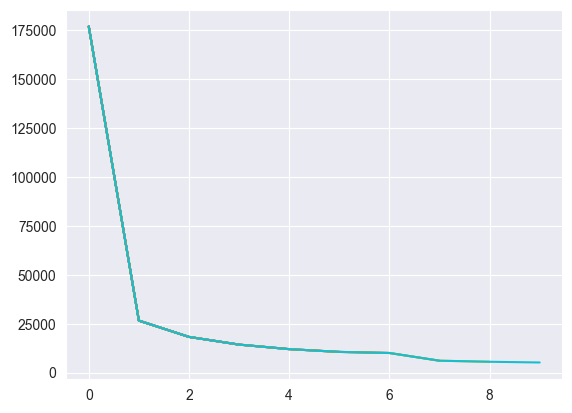

In [19]:
def calculate_inertias(df: pd.DataFrame) -> None:
    inertias = []
    for n_clusters in range(1, 11):
        cluster = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42, n_init="auto")
        cluster.fit(df[["latitude", "longitude"]])
        inertias.append(cluster.inertia_)
        inertias_dict = dict(zip(range(10), inertias))
        pd.Series(data=inertias_dict).plot()
    pass

calculate_inertias(df)

In [20]:
# The best value for n_clusters is 2

cluster = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init="auto")
cluster.fit(encoded_df[["latitude", "longitude"]])

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [21]:
centers = cluster.cluster_centers_
centers

array([[  33.93924372, -118.00637521],
       [  37.95483333, -121.71523908]])

In [22]:
encoded_df["cluster"] = cluster.transform(encoded_df[["latitude", "longitude"]]).argmax(axis=1)
encoded_df[["cluster_center_y", "cluster_center_x"]] = centers[encoded_df["cluster"]]
encoded_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster,cluster_center_y,cluster_center_x
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,2,0,33.939244,-118.006375
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,2,0,33.939244,-118.006375
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,2,0,33.939244,-118.006375
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,2,0,33.939244,-118.006375
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,2,0,33.939244,-118.006375


In [25]:
fig = px.scatter_map(encoded_df, lat="latitude", lon="longitude", color="cluster")
fig.add_trace(
    go.Scattergeo(
        lat=encoded_df["cluster_center_y"],
        lon=encoded_df["cluster_center_x"],
        mode="markers",
        marker=go.scattergeo.Marker(size=10, color="red", symbol="star"),
        name="Cluster centers",
        )
    )
fig.update_layout(height=600, width=1200, title_text="Median house value by location")
fig.show()

In [26]:
# It seems the best option to discard the clusters from KMeans, as it's suggesting just 2. Let's try with another cluster method.

In [27]:
density_cluster = DBSCAN(eps=0.1, min_samples=5, metric="euclidean")
clusters = density_cluster.fit_predict(df[["latitude", "longitude"]])
encoded_df["clusters"] = clusters

In [28]:
fig = px.scatter_map(encoded_df, lat="latitude", lon="longitude", color="clusters")
fig.update_layout(height=600, width=1200, title_text="DBSCAN clusters")
fig.show()

In [29]:
# Drop previous clusters columns from Kmeans plus latitude and longitude.
encoded_df.drop(["latitude", "longitude", "cluster", "cluster_center_y", "cluster_center_x"], axis=1, inplace=True)

In [30]:
encoded_df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,clusters
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,2,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,2,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,2,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,2,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,2,0


### ML + Feature importance

In [31]:
def create_dmatrix_sets(df: pd.DataFrame):
    """
    Create DMatrix datasets for training and testing.

    This function takes a pandas DataFrame, performs necessary preprocessing
    through the `clean_dataframe` function, and splits the resulting DataFrame
    into training and testing sets. The training and testing datasets are further
    converted into XGBoost DMatrix objects for model training and evaluation.

    :param df: The input pandas DataFrame containing raw data. It is expected to
        have a column named "AveragePrice" as the target value.

    :return: A tuple containing two xgboost.DMatrix objects: `dtrain` for the
        training set and `dtest` for the testing set.
    """
    df = df.copy()
    df_train = df.sample(frac=0.7)
    df_test = df.drop(df_train.index)

    print(f"Training set size: {len(df_train)}\nTest set size: {len(df_test)}")

    X_train = df_train
    Y_train = df_train.pop(target)
    X_test = df_test
    Y_test = df_test.pop(target)

    dtrain = xgb.DMatrix(X_train, label=Y_train)
    dtest = xgb.DMatrix(X_test, label=Y_test)

    return dtrain, dtest

In [32]:
dtrain, dtest = create_dmatrix_sets(encoded_df)

Training set size: 14448
Test set size: 6192


In [33]:
def objective(trial):

    num_round = 200
    evallist = [(dtrain, 'train'), (dtest, 'eval')]
    param = {
        "tree_method": "hist",
        "device": "cuda",
        "verbosity": 0,
        "objective": "reg:squaredlogerror",
        # defines booster, gblinear for linear functions.
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        # L2 regularization weight.
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        # L1 regularization weight.
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        # sampling ratio for training data.
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        # sampling according to each tree.
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
    }

    if param["booster"] in ["gbtree", "dart"]:
        # maximum depth of the tree, signifies complexity of the tree.
        param["max_depth"] = trial.suggest_int("max_depth", 3, 9, step=2)
        # minimum child weight, larger the term more conservative the tree.
        param["min_child_weight"] = trial.suggest_int("min_child_weight", 2, 10)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0, log=True)
        # defines how selective algorithm is.
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0, log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0, log=True)


    bst = xgb.train(params=param,
                    dtrain=dtrain,
                    num_boost_round=num_round,
                    evals=evallist,
                    early_stopping_rounds=10,
                    verbose_eval=False)

    ypred = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

    return root_mean_squared_error(ypred, dtest.get_label())

In [34]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2025-08-25 21:09:45,564] A new study created in memory with name: no-name-44495376-d61e-4c17-aa52-7f2056f839ab
[I 2025-08-25 21:10:09,387] Trial 0 finished with value: 238271.8125 and parameters: {'booster': 'dart', 'lambda': 0.00022906770705930906, 'alpha': 0.0032807410245541857, 'subsample': 0.6634112960779648, 'colsample_bytree': 0.8289691215680717, 'max_depth': 9, 'min_child_weight': 4, 'eta': 0.0008230152539186734, 'gamma': 7.073066582974717e-07, 'grow_policy': 'depthwise', 'sample_type': 'weighted', 'normalize_type': 'tree', 'rate_drop': 1.1887417071603892e-08, 'skip_drop': 0.0037592012229534237}. Best is trial 0 with value: 238271.8125.
[I 2025-08-25 21:10:34,507] Trial 1 finished with value: 238272.09375 and parameters: {'booster': 'dart', 'lambda': 5.435858854090847e-08, 'alpha': 0.28250851121262993, 'subsample': 0.6040615868570203, 'colsample_bytree': 0.8508574507486544, 'max_depth': 7, 'min_child_weight': 10, 'eta': 1.6865656868590368e-06, 'gamma': 0.001548175800399971, '

In [35]:
best_params = study.best_params
best_params["tree_method"] = "hist"
best_params["device"] = "cuda"
best_params["objective"] = "reg:squaredlogerror"
best_params

{'booster': 'gblinear',
 'lambda': 5.624246176092608e-08,
 'alpha': 6.299036367141472e-05,
 'subsample': 0.970418133317094,
 'colsample_bytree': 0.5395256213770989,
 'tree_method': 'hist',
 'device': 'cuda',
 'objective': 'reg:squaredlogerror'}

In [36]:
def train_model(dtrain, dtest, params):
    evallist = [(dtrain, 'train'), (dtest, 'eval')]
    bst = xgb.train(params=params,
                    dtrain=dtrain,
                    num_boost_round=200,
                    evals=evallist,
                    early_stopping_rounds=10,
                    verbose_eval=False)
    return bst

bst = train_model(dtrain, dtest, best_params)

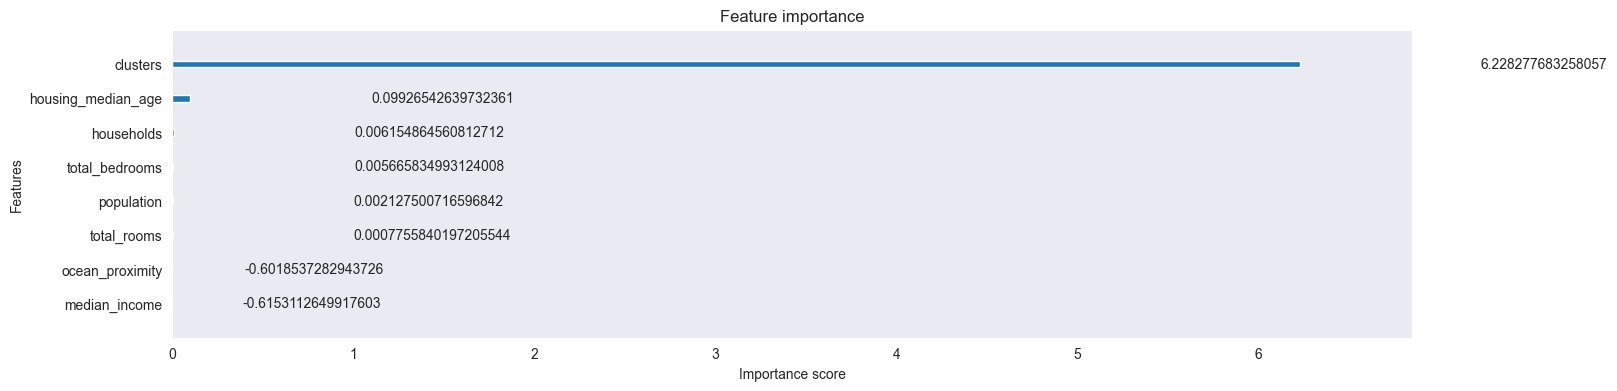

In [37]:
_, ax = plt.subplots(figsize=(16, 4))
xgb.plot_importance(bst, ax=ax)
ax.grid(False)
plt.show()